# L3_9_2_VC_and_PE_Exit_Prediction_distribution

This notebook builds the features that are supported by `data/live_root` only, constructs the paper-style label, and evaluates Logistic Regression, SVM with an RBF kernel, and XGBoost on mature out-of-time rolling windows.

In [17]:
from __future__ import annotations

import hashlib
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except Exception as exc:
    XGBClassifier = None
    print(f"XGBoost unavailable: {exc}")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [18]:
REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parents[1]
elif not (REPO_ROOT / "data" / "live_root").exists():
    # Allows running from project/notebooks or the repo root.
    REPO_ROOT = Path("D:/Columbia/SummerProject/L3_9_2_VC_and_PE_Exit_Prediction_distribution")

LIVE_ROOT = REPO_ROOT / "data" / "live_root"
CB_ROOT = LIVE_ROOT / "CrunchBase"
PREQIN_ROOT = LIVE_ROOT / "WRDS" / "Preqin"
PATENT_PATH = LIVE_ROOT / "WRDS" / "WRDS - Patents" / "wrdsapps.patents.csv"

OUTPUT_DIR = REPO_ROOT / "outputs" / "live_root_harness"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PANEL_MODE = "rolling_year"  # "company_snapshot" or "rolling_year"
ROLLING_OBSERVATION_FREQ = "YS" # frequency of the rolling observation window, e.g. "YS" for yearly, "QS" for quarterly
ROLLING_MIN_AGE_YEARS = 0 # minimum age of the company in years for the rolling observation window
LABEL_HORIZON_YEARS = 5 # censorship years for the label horizon
MIN_TEST_YEAR = 2013
TEST_WINDOW_YEARS = 2
MIN_TRAIN_ROWS = 1000
MIN_TEST_ROWS = 200
PRECISION_K = 500
BOOTSTRAP_REPS = 500
RANDOM_SEED = 17
FAST_DEV_RUN = False
FAST_DEV_MAX_WINDOWS = 3
MIN_PROMOTION_DELTA = 0.01
MIN_PROMOTION_CI_LOWER = 0.0025
MIN_POSITIVE_ORIGIN_SHARE = 0.75
PLACEBO_PASS_IS_FATAL = False
MAX_TRAIN_ROWS_BY_MODEL = {
    "logistic_regression": 150_000,
    "svm_rbf": 8_000,
    "xgboost": 80_000,
}

print(LIVE_ROOT)


d:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\data\live_root


## Helper Functions

In [19]:
def normalize_name(value: object) -> str | None:
    if pd.isna(value):
        return None
    text = str(value).lower()
    text = re.sub(r"&", " and ", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\b(inc|incorporated|llc|ltd|limited|corp|corporation|co|company|plc|sa|ag|gmbh|holdings|holding)\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or None


def normalize_domain(value: object) -> str | None:
    if pd.isna(value):
        return None
    text = str(value).strip().lower()
    text = re.sub(r"^https?://", "", text)
    text = re.sub(r"^www\.", "", text)
    text = text.split("/")[0].split("?")[0].strip()
    return text or None


def stable_noise(key: object) -> float:
    digest = hashlib.sha256(str(key).encode("utf-8")).digest()
    integer = int.from_bytes(digest[:8], "little", signed=False)
    return (integer / 2**64) * 2 - 1


def as_tz_naive(value: object) -> pd.Timestamp:
    ts = pd.to_datetime(value, errors="coerce")
    if pd.isna(ts):
        return pd.NaT
    if getattr(ts, "tzinfo", None) is not None:
        return ts.tz_convert(None)
    return ts


def safe_auc(y_true: pd.Series, score: np.ndarray) -> float:
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return float(roc_auc_score(y_true, score))


def precision_at_k(y_true: pd.Series, score: np.ndarray, k: int = PRECISION_K) -> float:
    frame = pd.DataFrame({"y": np.asarray(y_true), "score": np.asarray(score)})
    if frame.empty:
        return np.nan
    top = frame.sort_values("score", ascending=False).head(min(k, len(frame)))
    return float(top["y"].mean())


def expected_calibration_error(y_true: pd.Series, score: np.ndarray, bins: int = 10) -> float:
    frame = pd.DataFrame({"y": np.asarray(y_true), "score": np.asarray(score)})
    frame = frame.dropna()
    if frame.empty:
        return np.nan
    frame["bin"] = pd.qcut(frame["score"].rank(method="first"), q=bins, duplicates="drop")
    grouped = frame.groupby("bin", observed=True).agg(rows=("y", "size"), event_rate=("y", "mean"), mean_score=("score", "mean"))
    return float((grouped["rows"] / grouped["rows"].sum() * (grouped["event_rate"] - grouped["mean_score"]).abs()).sum())


def bootstrap_delta_ci(base_frame: pd.DataFrame, alt_frame: pd.DataFrame, k: int = PRECISION_K, reps: int = BOOTSTRAP_REPS) -> tuple[float, float, float]:
    key_col = "observation_id" if "observation_id" in base_frame.columns and "observation_id" in alt_frame.columns else "company_uuid"
    merged = base_frame[[key_col, "y", "score"]].rename(columns={"score": "score_base"}).merge(
        alt_frame[[key_col, "score"]].rename(columns={"score": "score_alt"}), on=key_col, how="inner"
    )
    if merged.empty:
        return np.nan, np.nan, np.nan
    point = precision_at_k(merged["y"], merged["score_alt"], k) - precision_at_k(merged["y"], merged["score_base"], k)
    rng = np.random.default_rng(RANDOM_SEED)
    deltas = []
    n = len(merged)
    for _ in range(reps):
        idx = rng.integers(0, n, n)
        sample = merged.iloc[idx]
        deltas.append(precision_at_k(sample["y"], sample["score_alt"], k) - precision_at_k(sample["y"], sample["score_base"], k))
    lo, hi = np.nanpercentile(deltas, [2.5, 97.5])
    return float(point), float(lo), float(hi)


def residualize_on_groups(values: pd.Series, groups: pd.Series) -> pd.Series:
    frame = pd.DataFrame({"value": pd.to_numeric(values, errors="coerce"), "group": groups.astype(str)})
    global_mean = frame["value"].mean()
    group_mean = frame.groupby("group")["value"].transform("mean")
    return frame["value"] - group_mean + global_mean


def residual_rank_ic(frame: pd.DataFrame, feature: str, label: str = "y") -> float:
    required = frame[[feature, label, "sector_stage_cohort"]].dropna()
    if len(required) < 50 or required[feature].nunique() < 3 or required[label].nunique() < 2:
        return np.nan
    x_resid = residualize_on_groups(required[feature], required["sector_stage_cohort"])
    y_resid = residualize_on_groups(required[label], required["sector_stage_cohort"])
    return float(x_resid.rank().corr(y_resid.rank()))


## Load Live Root Data

In [20]:
companies = pd.read_csv(CB_ROOT / "companies.csv", parse_dates=["founded_on", "last_funding_at", "collected_at"])
rounds = pd.read_csv(CB_ROOT / "funding_rounds.csv", parse_dates=["announced_on"])
acq = pd.read_csv(CB_ROOT / "acquisitions.csv", parse_dates=["announced_on"])
ipos = pd.read_csv(CB_ROOT / "ipos.csv", parse_dates=["went_public_on"])

vc_deals = pd.read_csv(PREQIN_ROOT / "Venture Capital Deals" / "Venture Capital Deals.csv", parse_dates=["deal_date"])
buyout_deals = pd.read_csv(PREQIN_ROOT / "Buyout Deals" / "Buyout Deals.csv", parse_dates=["deal_date"])

print("companies", companies.shape)
print("rounds", rounds.shape)
print("acquisitions", acq.shape)
print("ipos", ipos.shape)
print("preqin vc", vc_deals.shape)
print("preqin buyout", buyout_deals.shape)


C:\Users\heshe\AppData\Local\Temp\ipykernel_38568\2449519487.py:1: DtypeWarning: Columns (0: operating_status) have mixed types. Specify dtype option on import or set low_memory=False.
  companies = pd.read_csv(CB_ROOT / "companies.csv", parse_dates=["founded_on", "last_funding_at", "collected_at"])


companies (574938, 11)
rounds (789273, 5)
acquisitions (202620, 4)
ipos (55296, 4)
preqin vc (370780, 25)
preqin buyout (130983, 41)


## Build Review Panel and Label

The notebook supports a one-row-per-company snapshot mode and a rolling annual panel mode. Features are measured as of each row's review date. The label is evaluated within a fixed maturity horizon so rolling windows are not contaminated by immature cohorts.

In [21]:
rounds = rounds.dropna(subset=["company_uuid", "announced_on"]).copy()
rounds["money_raised_usd"] = pd.to_numeric(rounds["money_raised_usd"], errors="coerce")
rounds["num_investors"] = pd.to_numeric(rounds["num_investors"], errors="coerce")

first_round = rounds.sort_values(["company_uuid", "announced_on"]).groupby("company_uuid", as_index=False).first()[
    ["company_uuid", "announced_on", "investment_type", "money_raised_usd", "num_investors"]
].rename(columns={
    "announced_on": "first_funding_date",
    "investment_type": "first_stage",
    "money_raised_usd": "first_round_amount_usd",
    "num_investors": "first_round_num_investors",
})

company_base = companies.merge(first_round, on="company_uuid", how="left")
company_base["company_start_date"] = company_base["first_funding_date"].fillna(company_base["founded_on"])
company_base = company_base.dropna(subset=["company_uuid", "company_start_date", "founded_on"]).copy()

data_asof_candidates = [
    companies["collected_at"].max(),
    rounds["announced_on"].max(),
    acq["announced_on"].max(),
    ipos["went_public_on"].max(),
]
data_asof_candidates = [as_tz_naive(x) for x in data_asof_candidates]
DATA_ASOF = min([x for x in data_asof_candidates if pd.notna(x)])
if PANEL_MODE == "company_snapshot":
    base = company_base.copy()
    base["review_date"] = base["company_start_date"]
elif PANEL_MODE == "rolling_year":
    panel_rows = []
    max_review_date = DATA_ASOF - pd.DateOffset(years=LABEL_HORIZON_YEARS)
    for row in company_base.itertuples(index=False):
        start = max(pd.Timestamp(row.company_start_date), pd.Timestamp(row.founded_on) + pd.DateOffset(years=ROLLING_MIN_AGE_YEARS))
        first_obs = start if start.is_year_start else pd.Timestamp(year=start.year + 1, month=1, day=1)
        if pd.isna(first_obs) or first_obs > max_review_date:
            continue
        for review_date in pd.date_range(first_obs, max_review_date, freq=ROLLING_OBSERVATION_FREQ):
            item = row._asdict()
            item["review_date"] = review_date
            panel_rows.append(item)
    base = pd.DataFrame(panel_rows)
else:
    raise ValueError(f"Unsupported PANEL_MODE: {PANEL_MODE}")

base["review_date"] = pd.to_datetime(base["review_date"], errors="coerce")
base["label_cutoff"] = base["review_date"] + pd.DateOffset(years=LABEL_HORIZON_YEARS)
base = base[base["label_cutoff"] <= DATA_ASOF].copy()
base["observation_id"] = base["company_uuid"].astype(str) + "::" + base["review_date"].dt.strftime("%Y-%m-%d")

acq_first = acq.dropna(subset=["acquiree_uuid", "announced_on"]).groupby("acquiree_uuid", as_index=False)["announced_on"].min().rename(
    columns={"acquiree_uuid": "company_uuid", "announced_on": "first_acquisition_date"}
)
ipo_first = ipos.dropna(subset=["company_uuid", "went_public_on"]).groupby("company_uuid", as_index=False)["went_public_on"].min().rename(
    columns={"went_public_on": "first_ipo_date"}
)
series_b_first = rounds[rounds["investment_type"].astype(str).str.lower().eq("series_b")].groupby("company_uuid", as_index=False)["announced_on"].min().rename(
    columns={"announced_on": "first_series_b_date"}
)

base = base.merge(acq_first, on="company_uuid", how="left").merge(ipo_first, on="company_uuid", how="left").merge(series_b_first, on="company_uuid", how="left")
base["label_acquired_horizon"] = base["first_acquisition_date"].notna() & (base["first_acquisition_date"] >= base["review_date"]) & (base["first_acquisition_date"] <= base["label_cutoff"])
base["label_ipo_horizon"] = base["first_ipo_date"].notna() & (base["first_ipo_date"] >= base["review_date"]) & (base["first_ipo_date"] <= base["label_cutoff"])
base["label_series_b_horizon"] = (
    base["first_series_b_date"].notna()
    & (base["first_series_b_date"] >= base["review_date"])
    & (base["first_series_b_date"] <= base["label_cutoff"])
)
base["y"] = (base["label_acquired_horizon"] | base["label_ipo_horizon"] | base["label_series_b_horizon"]).astype(int)

print("DATA_ASOF", DATA_ASOF)
print(base[["y", "label_acquired_horizon", "label_ipo_horizon", "label_series_b_horizon"]].mean())
print("PANEL_MODE", PANEL_MODE)
print("rows", base.shape[0], "companies", base["company_uuid"].nunique())


DATA_ASOF 2026-04-17 00:00:00
y                         0.128874
label_acquired_horizon    0.095789
label_ipo_horizon         0.025254
label_series_b_horizon    0.009573
dtype: float64
PANEL_MODE rolling_year
rows 6173630 companies 384318


## Build Supported Feature Families

## Label and Feature Construction

### Label

Rows can be built in two modes. With `PANEL_MODE = "company_snapshot"`, each company has one review snapshot at the first known CrunchBase funding date, falling back to the founding date when no funding date is available. With `PANEL_MODE = "rolling_year"`, each company has annual review snapshots from its first eligible observation date through the last date whose full 5-year label horizon is mature. A row is kept only if the full 5-year label horizon is mature relative to the available data as-of date.

The main label is:

```text
y = 1 if acquisition within 5 years
      OR IPO within 5 years
      OR Series B within 5 years
    0 otherwise
```

`acquisition` uses `CrunchBase/acquisitions.csv: announced_on`; `IPO` uses `CrunchBase/ipos.csv: went_public_on`; `Series B` uses `CrunchBase/funding_rounds.csv: announced_on` where `investment_type == "series_b"`. The current `companies.operating_status` field is intentionally not used in the label because it is observed at collection time and can introduce look-ahead bias.

### Features

| Feature | Construction |
|---|---|
| `company_age_years_at_review` | Years from `founded_on` to `review_date`. |
| `sector_proxy` | Text proxy from company description: software/SaaS, healthcare/medical, financial/bank, or other. One-hot encoded in the model. |
| `stage_proxy` | Latest observed round stage as of `review_date`, falling back to first stage, then `unknown`. One-hot encoded in the model. |
| `cohort_bucket` | Three-year bucket of `review_date` year. One-hot encoded in the model. |
| `num_investors_last_round` | Number of investors in the latest funding round announced on or before `review_date`. |
| `round_velocity` | Number of rounds observed by `review_date` divided by company age at review. |
| `inter_round_gap_vs_cohort_z` | Latest inter-round gap, standardized using train-period mean and standard deviation within sector x stage cohorts for each rolling window. |
| `log_cum_raised_asof` | `log1p` of cumulative `money_raised_usd` from rounds announced on or before `review_date`. |
| `backward_cites_mean_at_grant` | Mean WRDS patent backward citations for exact normalized-name patent assignee matches with `grantdate <= review_date`. |
| `grant_lag_mean` | Mean days between patent `appldate` and `grantdate` for patents granted by `review_date`. |
| `patent_grants_asof` | Count of matched patents with `grantdate <= review_date`. |
| `patent_coverage_missing_flag` | 1 when no matched patent grants are observed by review date, otherwise 0. |
| `crosswalk_matched` | Point-in-time Preqin-CrunchBase match indicator. VC and buyout Preqin deal rows are stacked with a retained `preqin_deal_source` flag, then the feature equals 1 only when the company can be uniquely matched by domain or normalized name + country and the earliest matched Preqin `deal_date` is on or before `review_date`. |
| `preqin_institutional_confirmation` | Alias for the point-in-time accepted Preqin-CrunchBase confirmation. |
| `preqin_deal_count_asof` | Count of matched Preqin VC/buyout deal rows with `deal_date <= review_date`. |
| `quarters_since_first_preqin_deal` | Quarters between earliest matched Preqin deal and `review_date`, set to 0 when no as-of Preqin confirmation exists. |
| `preqin_missing_flag` | 1 when no point-in-time Preqin confirmation exists, otherwise 0. |
| `log_revenue_at_entry` | Intended: `log1p(company_revenue)` from the latest matched buyout deal whose `deal_date + 2 quarters <= review_date`. Current package note: source table and entity matches exist, but required financial fields are fully missing, so this is filled as 0 and should be treated as unavailable. |
| `ebitda_margin_at_entry` | Intended: `ebitda / company_revenue` from the latest visible matched buyout deal. Current package note: required EBITDA/revenue values are fully missing, so this is filled as 0 and should be treated as unavailable. |
| `entry_multiple_vs_vintage_sector_median` | Intended: entry EBITDA multiple divided by the buyout deal's vintage-year x sector median, using only visible matched buyout deals. Current package note: entry EBITDA multiple is fully missing, so this is filled as 0 and should be treated as unavailable. |
| `buyout_fundamentals_missing_flag` | 1 when no visible matched buyout fundamentals are available, otherwise 0. Current package note: this flag is always 1 because all required buyout financial fields are missing. |
| `coverage_missing_flag` | General coverage placeholder retained for family-level missingness accounting. |
| `noise_placebo` | Deterministic random noise from `company_uuid`; used to test whether the promotion gate is too permissive. |

All event-based features are constructed using information dated on or before each row's `review_date`; train-period cohort statistics are recomputed inside each rolling window. Out-of-time training rows are also required to have `label_cutoff < test_start_date`, so the model never trains on labels that would only mature during or after the test window.

### Requested Features Not Built From Current `live_root`

| Requested feature | Status in this notebook | Missing source requirement |
|---|---|---|
| `lead_prior_hard_exit_rate_asof` | Not built | Requires `funding_rounds_search.lead_investor_identifiers_json` or equivalent lead-investor identifiers. |
| `syndicate_investor_centrality_max` | Not built | Requires `investments_search` or another round-investor edge list. |
| `insider_only_round_flag` | Not built | Requires latest and prior round investor sets. |
| `has_lead_investor_flag` | Not built | Requires lead-investor identifiers. |
| `founder_count` | Not built | Requires `organization_fields.num_founders`; not present in current `live_root/CrunchBase/companies.csv`. |
| `founder_prior_founding_count`, `founder_prior_exit_flag` | Not built | Requires `organization_founders`, `jobs_search`, and dated/self-excluded founder role history. |
| `valuation_step_up_last` | Not built | Requires post-money valuation fields from `investor_participated_funding_rounds`. |
| `preqin_cb_funding_discrepancy` | Deferred | Needs a stricter matched-round bridge between Preqin deals and CrunchBase rounds before using as a feature. |
| `deal_stage_crosscheck_flag` | Deferred | Needs a matched-round bridge between Preqin `deal_stage` and CrunchBase `investment_type`. |


In [22]:
review_dates = base[["observation_id", "company_uuid", "review_date"]].drop_duplicates("observation_id")

rounds_for_snap = rounds.sort_values(["company_uuid", "announced_on"]).copy()
rounds_for_snap["round_gap_years"] = rounds_for_snap.groupby("company_uuid")["announced_on"].diff().dt.days / 365.25
rounds_for_snap = rounds_for_snap.merge(review_dates, on="company_uuid", how="inner")
rounds_asof = rounds_for_snap[rounds_for_snap["announced_on"] <= rounds_for_snap["review_date"]].copy()

latest = rounds_asof.sort_values(["observation_id", "announced_on"]).groupby("observation_id", as_index=False).tail(1)[
    ["observation_id", "announced_on", "investment_type", "num_investors", "round_gap_years"]
].rename(columns={
    "announced_on": "latest_round_date",
    "investment_type": "latest_stage",
    "num_investors": "num_investors_last_round",
    "round_gap_years": "latest_inter_round_gap_years",
})

agg = rounds_asof.groupby("observation_id", as_index=False).agg(
    round_count_asof=("announced_on", "size"),
    cum_raised_asof=("money_raised_usd", lambda s: s.fillna(0).clip(lower=0).sum()),
)
agg["round_count_asof"] = agg["round_count_asof"].astype(float)
agg["log_cum_raised_asof"] = np.log1p(agg["cum_raised_asof"])
snap = latest.merge(agg[["observation_id", "round_count_asof", "log_cum_raised_asof"]], on="observation_id", how="outer")

features = base.merge(snap, on="observation_id", how="left")
features["company_age_years_at_review"] = (features["review_date"] - features["founded_on"]).dt.days.clip(lower=0) / 365.25
features["round_velocity"] = features["round_count_asof"] / features["company_age_years_at_review"].replace(0, np.nan)
features["round_velocity"] = features["round_velocity"].replace([np.inf, -np.inf], np.nan)

features["sector_proxy"] = features["description"].fillna("").str.lower().map(lambda s: "software" if "software" in s or "saas" in s else ("healthcare" if "health" in s or "medical" in s else ("financial" if "financ" in s or "bank" in s else "other")))
features["stage_proxy"] = features["latest_stage"].fillna(features["first_stage"]).fillna("unknown").astype(str)
features["cohort_year"] = features["review_date"].dt.year.astype(int)
features["cohort_bucket"] = (features["cohort_year"] // 3 * 3).astype(str)
features["sector_stage_cohort"] = features["sector_proxy"] + "|" + features["stage_proxy"] + "|" + features["cohort_bucket"]

# Train-period cohort stats are recomputed inside each rolling window. This global placeholder is overwritten later for modeling.
features["inter_round_gap_vs_cohort_z"] = np.nan

print(features[["num_investors_last_round", "log_cum_raised_asof", "round_velocity", "latest_inter_round_gap_years"]].describe())


       num_investors_last_round  log_cum_raised_asof  round_velocity  latest_inter_round_gap_years
count              1.139464e+06         1.520620e+06    1.512281e+06                 529775.000000
mean               1.859988e+00         1.006825e+01    3.817512e-01                      1.646329
std                1.825595e+00         6.987813e+00    1.887550e+00                      1.788803
min                1.000000e+00         0.000000e+00    1.048238e-03                      0.000000
25%                1.000000e+00         0.000000e+00    1.000000e-01                      0.651608
50%                1.000000e+00         1.311232e+01    2.103975e-01                      1.166324
75%                2.000000e+00         1.552026e+01    4.863515e-01                      2.001369
max                9.700000e+01         2.532844e+01    9.131250e+02                     38.332649


In [23]:
# Preqin-CrunchBase crosswalk indicator, point-in-time safe by earliest Preqin deal date.
preqin_company_cols = ["portfolio_company_id", "portfolio_company_name", "portfolio_company_website", "portfolio_company_country", "deal_date"]
preqin_vc_companies = vc_deals[preqin_company_cols].copy()
preqin_vc_companies["preqin_deal_source"] = "vc"
preqin_buyout_companies = buyout_deals[preqin_company_cols].copy()
preqin_buyout_companies["preqin_deal_source"] = "buyout"
preqin_companies = pd.concat([preqin_vc_companies, preqin_buyout_companies], ignore_index=True).drop_duplicates()
preqin_companies["norm_domain"] = preqin_companies["portfolio_company_website"].map(normalize_domain)
preqin_companies["norm_name"] = preqin_companies["portfolio_company_name"].map(normalize_name)
preqin_companies["country_key"] = preqin_companies["portfolio_company_country"].astype(str).str.lower()
preqin_companies["deal_date"] = pd.to_datetime(preqin_companies["deal_date"], errors="coerce")

features["norm_domain"] = features["website"].map(normalize_domain)
features["norm_name"] = features["name"].map(normalize_name)
features["country_key"] = features["hq_country"].astype(str).str.lower()

preqin_domain_first = preqin_companies.dropna(subset=["norm_domain", "deal_date"]).groupby("norm_domain").agg(
    preqin_first_deal_date=("deal_date", "min"),
    preqin_company_count=("portfolio_company_id", "nunique"),
).reset_index()
cb_domain_counts = features.dropna(subset=["norm_domain"]).groupby("norm_domain")["company_uuid"].nunique().rename("cb_company_count").reset_index()
domain_matches = preqin_domain_first.merge(cb_domain_counts, on="norm_domain", how="inner")
domain_matches = domain_matches[(domain_matches["preqin_company_count"] == 1) & (domain_matches["cb_company_count"] == 1)][["norm_domain", "preqin_first_deal_date"]]

preqin_name_first = preqin_companies.dropna(subset=["norm_name", "deal_date"]).groupby(["norm_name", "country_key"]).agg(
    preqin_first_deal_date=("deal_date", "min"),
    preqin_company_count=("portfolio_company_id", "nunique"),
).reset_index()
cb_name_counts = features.dropna(subset=["norm_name"]).groupby(["norm_name", "country_key"])["company_uuid"].nunique().rename("cb_company_count").reset_index()
name_matches = preqin_name_first.merge(cb_name_counts, on=["norm_name", "country_key"], how="inner")
name_matches = name_matches[(name_matches["preqin_company_count"] == 1) & (name_matches["cb_company_count"] == 1)][["norm_name", "country_key", "preqin_first_deal_date"]]

features = features.merge(domain_matches.rename(columns={"preqin_first_deal_date": "preqin_first_deal_date_domain"}), on="norm_domain", how="left")
features = features.merge(name_matches.rename(columns={"preqin_first_deal_date": "preqin_first_deal_date_name"}), on=["norm_name", "country_key"], how="left")
features["preqin_first_deal_date"] = features[["preqin_first_deal_date_domain", "preqin_first_deal_date_name"]].min(axis=1)
features["crosswalk_matched_asof"] = (features["preqin_first_deal_date"].notna() & (features["preqin_first_deal_date"] <= features["review_date"])).astype(int)
features["crosswalk_matched"] = features["crosswalk_matched_asof"]
features["preqin_institutional_confirmation"] = features["crosswalk_matched_asof"]
features["quarters_since_first_preqin_deal"] = ((features["review_date"] - features["preqin_first_deal_date"]).dt.days / 91.3125).where(features["crosswalk_matched_asof"].eq(1), np.nan)

preqin_event_rows = []
domain_event_source = preqin_companies.dropna(subset=["norm_domain", "deal_date"]).merge(domain_matches[["norm_domain"]], on="norm_domain", how="inner")
domain_event_matches = features[["observation_id", "company_uuid", "norm_domain", "review_date"]].dropna(subset=["norm_domain"]).merge(
    domain_event_source[["norm_domain", "deal_date"]], on="norm_domain", how="inner"
)
preqin_event_rows.append(domain_event_matches)
name_event_source = preqin_companies.dropna(subset=["norm_name", "deal_date"]).merge(name_matches[["norm_name", "country_key"]], on=["norm_name", "country_key"], how="inner")
name_event_matches = features[["observation_id", "company_uuid", "norm_name", "country_key", "review_date"]].dropna(subset=["norm_name"]).merge(
    name_event_source[["norm_name", "country_key", "deal_date"]], on=["norm_name", "country_key"], how="inner"
)
preqin_event_rows.append(name_event_matches[["observation_id", "company_uuid", "review_date", "deal_date"]])
preqin_events_asof = pd.concat([frame[["observation_id", "company_uuid", "review_date", "deal_date"]] for frame in preqin_event_rows if not frame.empty], ignore_index=True).drop_duplicates()
preqin_events_asof = preqin_events_asof[preqin_events_asof["deal_date"] <= preqin_events_asof["review_date"]].copy()
preqin_deal_count = preqin_events_asof.groupby("observation_id", as_index=False).agg(preqin_deal_count_asof=("deal_date", "size"))
features = features.merge(preqin_deal_count, on="observation_id", how="left")
features["preqin_deal_count_asof"] = features["preqin_deal_count_asof"].fillna(0).astype(float)
features["preqin_missing_flag"] = 1 - features["preqin_institutional_confirmation"]
features["quarters_since_first_preqin_deal"] = features["quarters_since_first_preqin_deal"].fillna(0)

features["coverage_missing_flag"] = 0
features["noise_placebo"] = features["company_uuid"].map(stable_noise)

print(features["crosswalk_matched_asof"].value_counts(dropna=False))


crosswalk_matched_asof
0    5482482
1     691148
Name: count, dtype: int64


### Preqin-CrunchBase Crosswalk Audit

This audit table lists every accepted company-level Preqin-CrunchBase match and separates matches by `domain`, `normalized_name_country`, or both. It is for manual entity-link review and coverage diagnostics; the model feature remains the point-in-time `crosswalk_matched_asof` / `preqin_institutional_confirmation` indicator.


In [ ]:
# Preqin-CrunchBase crosswalk audit: company list and counts by match rule.
cb_company_keys = features[[
    "company_uuid", "name", "website", "hq_country",
    "norm_domain", "norm_name", "country_key",
    "preqin_first_deal_date_domain", "preqin_first_deal_date_name",
]].drop_duplicates("company_uuid").copy()

cb_company_keys["domain_match"] = cb_company_keys["preqin_first_deal_date_domain"].notna()
cb_company_keys["name_country_match"] = cb_company_keys["preqin_first_deal_date_name"].notna()

cb_company_keys["match_method"] = np.select(
    [
        cb_company_keys["domain_match"] & cb_company_keys["name_country_match"],
        cb_company_keys["domain_match"],
        cb_company_keys["name_country_match"],
    ],
    ["both_domain_and_name_country", "domain", "normalized_name_country"],
    default="none",
)

matched_companies = cb_company_keys[cb_company_keys["match_method"].ne("none")].copy()
matched_companies["preqin_first_deal_date"] = matched_companies[
    ["preqin_first_deal_date_domain", "preqin_first_deal_date_name"]
].min(axis=1)

preqin_domain_detail = (
    preqin_companies
    .dropna(subset=["norm_domain", "deal_date"])
    .sort_values(["norm_domain", "deal_date"])
    .groupby("norm_domain", as_index=False)
    .agg(
        preqin_portfolio_company_id=("portfolio_company_id", "first"),
        preqin_portfolio_company_name=("portfolio_company_name", "first"),
        preqin_portfolio_company_website=("portfolio_company_website", "first"),
        preqin_portfolio_company_country=("portfolio_company_country", "first"),
        preqin_deal_source=("preqin_deal_source", lambda s: ",".join(sorted(set(s.dropna().astype(str))))),
        preqin_first_deal_date=("deal_date", "min"),
    )
)

preqin_name_detail = (
    preqin_companies
    .dropna(subset=["norm_name", "country_key", "deal_date"])
    .sort_values(["norm_name", "country_key", "deal_date"])
    .groupby(["norm_name", "country_key"], as_index=False)
    .agg(
        preqin_portfolio_company_id=("portfolio_company_id", "first"),
        preqin_portfolio_company_name=("portfolio_company_name", "first"),
        preqin_portfolio_company_website=("portfolio_company_website", "first"),
        preqin_portfolio_company_country=("portfolio_company_country", "first"),
        preqin_deal_source=("preqin_deal_source", lambda s: ",".join(sorted(set(s.dropna().astype(str))))),
        preqin_first_deal_date=("deal_date", "min"),
    )
)

domain_audit = (
    matched_companies[matched_companies["domain_match"]]
    .merge(preqin_domain_detail, on="norm_domain", how="left", suffixes=("", "_preqin_domain"))
)
domain_audit["audit_match_type"] = "domain"

name_audit = (
    matched_companies[matched_companies["name_country_match"]]
    .merge(preqin_name_detail, on=["norm_name", "country_key"], how="left", suffixes=("", "_preqin_name"))
)
name_audit["audit_match_type"] = "normalized_name_country"

crosswalk_audit = pd.concat([domain_audit, name_audit], ignore_index=True, sort=False)

total_cb_companies = int(cb_company_keys["company_uuid"].nunique())
total_matched_companies = int(matched_companies["company_uuid"].nunique())

crosswalk_summary = pd.DataFrame([{
    "total_cb_companies": total_cb_companies,
    "matched_companies": total_matched_companies,
    "unmatched_companies": total_cb_companies - total_matched_companies,
    "matched_company_share": total_matched_companies / total_cb_companies if total_cb_companies else np.nan,
}])

company_match_counts = (
    matched_companies["match_method"]
    .value_counts()
    .rename_axis("match_method")
    .reset_index(name="company_count")
)
company_match_counts["share_of_all_companies"] = company_match_counts["company_count"] / total_cb_companies if total_cb_companies else np.nan
company_match_counts["share_of_matched_companies"] = company_match_counts["company_count"] / total_matched_companies if total_matched_companies else np.nan

company_match_counts_total = pd.DataFrame([{
    "match_method": "total_matched",
    "company_count": total_matched_companies,
    "share_of_all_companies": total_matched_companies / total_cb_companies if total_cb_companies else np.nan,
    "share_of_matched_companies": 1.0 if total_matched_companies else np.nan,
}])
company_match_counts = pd.concat([company_match_counts, company_match_counts_total], ignore_index=True)

audit_match_type_counts = (
    crosswalk_audit["audit_match_type"]
    .value_counts()
    .rename_axis("audit_match_type")
    .reset_index(name="match_rows")
)
total_audit_rows = int(len(crosswalk_audit))
audit_match_type_counts["share_of_audit_rows"] = audit_match_type_counts["match_rows"] / total_audit_rows if total_audit_rows else np.nan
audit_match_type_counts["share_of_all_companies"] = audit_match_type_counts["match_rows"] / total_cb_companies if total_cb_companies else np.nan

print("Overall crosswalk coverage:")
display(crosswalk_summary)

print("Company-level accepted crosswalk counts:")
display(company_match_counts)

print("Audit rows by matching rule:")
display(audit_match_type_counts)

print("All matched companies:")
display(
    matched_companies.sort_values(["match_method", "name"])[[
        "company_uuid", "name", "website", "hq_country",
        "match_method", "norm_domain", "norm_name", "country_key",
        "preqin_first_deal_date_domain", "preqin_first_deal_date_name",
        "preqin_first_deal_date",
    ]]
)

print("Detailed Preqin-side audit rows:")
display(
    crosswalk_audit.sort_values(["audit_match_type", "name"])[[
        "audit_match_type",
        "company_uuid", "name", "website", "hq_country",
        "norm_domain", "norm_name", "country_key",
        "preqin_portfolio_company_id",
        "preqin_portfolio_company_name",
        "preqin_portfolio_company_website",
        "preqin_portfolio_company_country",
        "preqin_deal_source",
        "preqin_first_deal_date",
    ]]
)

matched_companies.to_csv(OUTPUT_DIR / "preqin_crosswalk_matched_companies.csv", index=False)
crosswalk_audit.to_csv(OUTPUT_DIR / "preqin_crosswalk_match_audit_rows.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "preqin_crosswalk_matched_companies.csv")
print(OUTPUT_DIR / "preqin_crosswalk_match_audit_rows.csv")


In [24]:
# Buyout fundamentals with a 2-quarter reporting buffer. These are sparse and evaluated as a separate family.
buyout_feature_source = buyout_deals.copy()
buyout_feature_source["norm_domain"] = buyout_feature_source["portfolio_company_website"].map(normalize_domain)
buyout_feature_source["norm_name"] = buyout_feature_source["portfolio_company_name"].map(normalize_name)
buyout_feature_source["country_key"] = buyout_feature_source["portfolio_company_country"].astype(str).str.lower()
for col in ["company_revenue", "ebitda", "entry_ebitda_multiple", "entry_revenue_multiple"]:
    buyout_feature_source[col] = pd.to_numeric(buyout_feature_source[col], errors="coerce")
buyout_feature_source["visible_date"] = buyout_feature_source["deal_date"] + pd.DateOffset(months=6)
buyout_feature_source["deal_year"] = buyout_feature_source["deal_date"].dt.year
median_multiple = buyout_feature_source.groupby(["deal_year", "primary_industry"], observed=True)["entry_ebitda_multiple"].median().rename("vintage_sector_median_multiple").reset_index()
buyout_feature_source = buyout_feature_source.merge(median_multiple, on=["deal_year", "primary_industry"], how="left")
buyout_feature_source["log_revenue_at_entry"] = np.log1p(buyout_feature_source["company_revenue"].clip(lower=0))
buyout_feature_source["ebitda_margin_at_entry"] = buyout_feature_source["ebitda"] / buyout_feature_source["company_revenue"].replace(0, np.nan)
buyout_feature_source["entry_multiple_vs_vintage_sector_median"] = buyout_feature_source["entry_ebitda_multiple"] / buyout_feature_source["vintage_sector_median_multiple"].replace(0, np.nan)

buyout_domain_source = buyout_feature_source.dropna(subset=["norm_domain", "visible_date"]).merge(domain_matches[["norm_domain"]], on="norm_domain", how="inner")
buyout_domain_matches = features[["observation_id", "company_uuid", "norm_domain", "review_date"]].dropna(subset=["norm_domain"]).merge(buyout_domain_source, on="norm_domain", how="inner")
buyout_name_source = buyout_feature_source.dropna(subset=["norm_name", "visible_date"]).merge(name_matches[["norm_name", "country_key"]], on=["norm_name", "country_key"], how="inner")
buyout_name_matches = features[["observation_id", "company_uuid", "norm_name", "country_key", "review_date"]].dropna(subset=["norm_name"]).merge(buyout_name_source, on=["norm_name", "country_key"], how="inner")
buyout_asof = pd.concat([buyout_domain_matches, buyout_name_matches], ignore_index=True, sort=False).drop_duplicates()
buyout_asof = buyout_asof[buyout_asof["visible_date"] <= buyout_asof["review_date"]].copy()
buyout_latest = buyout_asof.sort_values(["observation_id", "visible_date"]).groupby("observation_id", as_index=False).tail(1)[[
    "observation_id", "log_revenue_at_entry", "ebitda_margin_at_entry", "entry_multiple_vs_vintage_sector_median"
]]
features = features.merge(buyout_latest, on="observation_id", how="left")
features["buyout_fundamentals_missing_flag"] = features[["log_revenue_at_entry", "ebitda_margin_at_entry", "entry_multiple_vs_vintage_sector_median"]].isna().all(axis=1).astype(int)
features[["log_revenue_at_entry", "ebitda_margin_at_entry", "entry_multiple_vs_vintage_sector_median"]] = features[["log_revenue_at_entry", "ebitda_margin_at_entry", "entry_multiple_vs_vintage_sector_median"]].fillna(0)
print(features[["log_revenue_at_entry", "ebitda_margin_at_entry", "entry_multiple_vs_vintage_sector_median", "buyout_fundamentals_missing_flag"]].describe())


       log_revenue_at_entry  ebitda_margin_at_entry  entry_multiple_vs_vintage_sector_median  buyout_fundamentals_missing_flag
count             6173630.0               6173630.0                                6173630.0                         6173630.0
mean                    0.0                     0.0                                      0.0                               1.0
std                     0.0                     0.0                                      0.0                               0.0
min                     0.0                     0.0                                      0.0                               1.0
25%                     0.0                     0.0                                      0.0                               1.0
50%                     0.0                     0.0                                      0.0                               1.0
75%                     0.0                     0.0                                      0.0                   

### Buyout Fundamentals Availability Diagnostic

This diagnostic separates entity-level Preqin matching from the stricter requirements needed to build buyout fundamentals. A company can have a valid Preqin crosswalk but still have no usable `log_revenue_at_entry`, `ebitda_margin_at_entry`, or `entry_multiple_vs_vintage_sector_median` if the match comes from VC deals, if buyout financial fields are missing, or if the buyout deal is not visible by the review date after the two-quarter reporting buffer.


In [ ]:
# Buyout fundamentals availability diagnostic.
fundamental_cols = [
    "log_revenue_at_entry",
    "ebitda_margin_at_entry",
    "entry_multiple_vs_vintage_sector_median",
]

buyout_candidate_matches = pd.concat(
    [buyout_domain_matches, buyout_name_matches],
    ignore_index=True,
    sort=False,
).drop_duplicates()
buyout_candidate_visible = buyout_candidate_matches[
    buyout_candidate_matches["visible_date"] <= buyout_candidate_matches["review_date"]
].copy()

buyout_source_has_any_fundamental = buyout_feature_source[fundamental_cols].notna().any(axis=1)
buyout_candidate_has_any_fundamental = buyout_candidate_matches[fundamental_cols].notna().any(axis=1) if len(buyout_candidate_matches) else pd.Series(dtype=bool)
buyout_visible_has_any_fundamental = buyout_candidate_visible[fundamental_cols].notna().any(axis=1) if len(buyout_candidate_visible) else pd.Series(dtype=bool)

buyout_diag = pd.DataFrame([{
    "cb_observations_total": int(len(features)),
    "cb_companies_total": int(features["company_uuid"].nunique()),
    "preqin_crosswalk_observations_asof": int(features["crosswalk_matched_asof"].sum()) if "crosswalk_matched_asof" in features else np.nan,
    "preqin_crosswalk_companies_any": int(features.loc[features.get("crosswalk_matched_asof", pd.Series(0, index=features.index)).eq(1), "company_uuid"].nunique()) if "crosswalk_matched_asof" in features else np.nan,
    "buyout_rows_total": int(len(buyout_feature_source)),
    "buyout_companies_total": int(buyout_feature_source["portfolio_company_id"].nunique()) if "portfolio_company_id" in buyout_feature_source else np.nan,
    "buyout_rows_with_domain": int(buyout_feature_source["norm_domain"].notna().sum()),
    "buyout_rows_with_name_country": int(buyout_feature_source[["norm_name", "country_key"]].notna().all(axis=1).sum()),
    "buyout_rows_with_company_revenue": int(buyout_feature_source["company_revenue"].notna().sum()),
    "buyout_rows_with_ebitda": int(buyout_feature_source["ebitda"].notna().sum()),
    "buyout_rows_with_entry_ebitda_multiple": int(buyout_feature_source["entry_ebitda_multiple"].notna().sum()),
    "buyout_rows_with_any_fundamental": int(buyout_source_has_any_fundamental.sum()),
    "buyout_domain_source_rows_accepted": int(len(buyout_domain_source)),
    "buyout_name_source_rows_accepted": int(len(buyout_name_source)),
    "buyout_candidate_observation_rows_before_asof": int(len(buyout_candidate_matches)),
    "buyout_candidate_companies_before_asof": int(buyout_candidate_matches["company_uuid"].nunique()) if len(buyout_candidate_matches) else 0,
    "buyout_candidate_rows_with_any_fundamental_before_asof": int(buyout_candidate_has_any_fundamental.sum()) if len(buyout_candidate_matches) else 0,
    "buyout_visible_observation_rows_after_buffer": int(len(buyout_candidate_visible)),
    "buyout_visible_companies_after_buffer": int(buyout_candidate_visible["company_uuid"].nunique()) if len(buyout_candidate_visible) else 0,
    "buyout_visible_rows_with_any_fundamental_after_buffer": int(buyout_visible_has_any_fundamental.sum()) if len(buyout_candidate_visible) else 0,
    "final_observations_with_buyout_fundamentals": int(features["buyout_fundamentals_missing_flag"].eq(0).sum()),
    "final_companies_with_buyout_fundamentals": int(features.loc[features["buyout_fundamentals_missing_flag"].eq(0), "company_uuid"].nunique()),
}])

share_denoms = {
    "preqin_crosswalk_observation_share": ("preqin_crosswalk_observations_asof", "cb_observations_total"),
    "preqin_crosswalk_company_share": ("preqin_crosswalk_companies_any", "cb_companies_total"),
    "buyout_rows_with_any_fundamental_share": ("buyout_rows_with_any_fundamental", "buyout_rows_total"),
    "buyout_candidate_company_share": ("buyout_candidate_companies_before_asof", "cb_companies_total"),
    "buyout_visible_company_share_after_buffer": ("buyout_visible_companies_after_buffer", "cb_companies_total"),
    "final_observation_share_with_buyout_fundamentals": ("final_observations_with_buyout_fundamentals", "cb_observations_total"),
    "final_company_share_with_buyout_fundamentals": ("final_companies_with_buyout_fundamentals", "cb_companies_total"),
}
for share_col, (num_col, den_col) in share_denoms.items():
    denom = buyout_diag.loc[0, den_col]
    buyout_diag[share_col] = buyout_diag.loc[0, num_col] / denom if pd.notna(denom) and denom else np.nan

buyout_diag_long = buyout_diag.T.rename(columns={0: "value"})

print("Buyout fundamentals availability diagnostic:")
display(buyout_diag_long)

buyout_field_coverage = pd.DataFrame({
    "field": ["company_revenue", "ebitda", "entry_ebitda_multiple", "log_revenue_at_entry", "ebitda_margin_at_entry", "entry_multiple_vs_vintage_sector_median"],
    "non_null_rows_in_buyout_source": [
        int(buyout_feature_source["company_revenue"].notna().sum()),
        int(buyout_feature_source["ebitda"].notna().sum()),
        int(buyout_feature_source["entry_ebitda_multiple"].notna().sum()),
        int(buyout_feature_source["log_revenue_at_entry"].notna().sum()),
        int(buyout_feature_source["ebitda_margin_at_entry"].notna().sum()),
        int(buyout_feature_source["entry_multiple_vs_vintage_sector_median"].notna().sum()),
    ],
})
buyout_field_coverage["share_of_buyout_rows"] = buyout_field_coverage["non_null_rows_in_buyout_source"] / len(buyout_feature_source) if len(buyout_feature_source) else np.nan

print("Buyout source field coverage:")
display(buyout_field_coverage)

buyout_diag_long.to_csv(OUTPUT_DIR / "buyout_fundamentals_availability_diagnostic.csv")
buyout_field_coverage.to_csv(OUTPUT_DIR / "buyout_fundamentals_field_coverage.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "buyout_fundamentals_availability_diagnostic.csv")
print(OUTPUT_DIR / "buyout_fundamentals_field_coverage.csv")


In [25]:
# Patent quality features. This uses an exact normalized-name assignee match and grantdate <= review_date.
company_names = features[["observation_id", "company_uuid", "name", "review_date", "norm_name"]].dropna(subset=["norm_name"]).copy()
unique_norm_names = company_names.groupby("norm_name")["company_uuid"].nunique()
company_names = company_names[company_names["norm_name"].isin(unique_norm_names[unique_norm_names == 1].index)].copy()
candidate_names = set(company_names["norm_name"].unique())
patent_frames = []
usecols = ["patnum", "grantdate", "appldate", "ee_name", "backward_cites"]

for chunk in pd.read_csv(PATENT_PATH, usecols=usecols, chunksize=200_000):
    chunk["norm_name"] = chunk["ee_name"].map(normalize_name)
    chunk = chunk[chunk["norm_name"].isin(candidate_names)].copy()
    if chunk.empty:
        continue
    chunk["grantdate"] = pd.to_datetime(chunk["grantdate"], errors="coerce")
    chunk["appldate"] = pd.to_datetime(chunk["appldate"], errors="coerce")
    chunk["backward_cites"] = pd.to_numeric(chunk["backward_cites"], errors="coerce")
    patent_frames.append(chunk[["patnum", "grantdate", "appldate", "backward_cites", "norm_name"]])

if patent_frames:
    patent_matches = pd.concat(patent_frames, ignore_index=True).merge(company_names, on="norm_name", how="inner")
    patent_matches = patent_matches[patent_matches["grantdate"].notna() & (patent_matches["grantdate"] <= patent_matches["review_date"])].copy()
    patent_matches["grant_lag_days"] = (patent_matches["grantdate"] - patent_matches["appldate"]).dt.days
    patent_agg = patent_matches.groupby("observation_id", as_index=False).agg(
        backward_cites_mean_at_grant=("backward_cites", "mean"),
        grant_lag_mean=("grant_lag_days", "mean"),
        patent_grants_asof=("patnum", "nunique"),
    )
else:
    patent_agg = pd.DataFrame(columns=["observation_id", "backward_cites_mean_at_grant", "grant_lag_mean", "patent_grants_asof"])

features = features.merge(patent_agg, on="observation_id", how="left")
features["patent_coverage_missing_flag"] = features["patent_grants_asof"].isna().astype(int)
features[["backward_cites_mean_at_grant", "grant_lag_mean", "patent_grants_asof"]] = features[["backward_cites_mean_at_grant", "grant_lag_mean", "patent_grants_asof"]].fillna(0)

print(features[["backward_cites_mean_at_grant", "grant_lag_mean", "patent_grants_asof", "patent_coverage_missing_flag"]].describe())


       backward_cites_mean_at_grant  grant_lag_mean  patent_grants_asof  patent_coverage_missing_flag
count                  6.173630e+06    6.173630e+06        6.173630e+06                  6.173630e+06
mean                   3.411294e-01    1.569561e+01        1.529141e-01                  9.885740e-01
std                    6.747261e+00    1.581945e+02        1.180505e+01                  1.062801e-01
min                    0.000000e+00    0.000000e+00        0.000000e+00                  0.000000e+00
25%                    0.000000e+00    0.000000e+00        0.000000e+00                  1.000000e+00
50%                    0.000000e+00    0.000000e+00        0.000000e+00                  1.000000e+00
75%                    0.000000e+00    0.000000e+00        0.000000e+00                  1.000000e+00
max                    1.543033e+03    5.888000e+03        4.450000e+03                  1.000000e+00


## Feature Families and Rolling Windows

## Feature Set Contents

| Feature set | Included variables |
|---|---|
| `baseline` | `company_age_years_at_review`, `sector_proxy`, `stage_proxy`, `cohort_bucket` |
| `baseline + noise_placebo` | baseline + `noise_placebo` |
| `baseline + syndicate_investor_supported` | baseline + `num_investors_last_round` |
| `baseline + founder_funding_dynamics_supported` | baseline + `round_velocity`, `inter_round_gap_vs_cohort_z`, `log_cum_raised_asof` |
| `baseline + patent_quality` | baseline + `backward_cites_mean_at_grant`, `grant_lag_mean`, `patent_grants_asof`, `patent_coverage_missing_flag` |
| `baseline + preqin_institutional_confirmation` | baseline + `preqin_institutional_confirmation`, `preqin_deal_count_asof`, `quarters_since_first_preqin_deal`, `preqin_missing_flag` |
| `baseline + buyout_fundamentals` | baseline + `log_revenue_at_entry`, `ebitda_margin_at_entry`, `entry_multiple_vs_vintage_sector_median`, `buyout_fundamentals_missing_flag`; retained only as an availability diagnostic because current buyout financial fields are fully missing. |
| `baseline + all_real_features` | baseline + all supported real feature families above |

`sector_proxy`, `stage_proxy`, and `cohort_bucket` are categorical and are one-hot encoded inside the model pipeline. All other variables listed here are numeric.


In [ ]:
requested_feature_availability = pd.DataFrame([
    {"feature": "lead_prior_hard_exit_rate_asof", "status": "blocked_missing_source", "notebook_column": "", "note": "Requires lead investor identifiers from funding_rounds_search."},
    {"feature": "syndicate_investor_centrality_max", "status": "blocked_missing_source", "notebook_column": "", "note": "Requires investments_search round-investor edges."},
    {"feature": "round_velocity", "status": "built", "notebook_column": "round_velocity", "note": "Built from live_root funding_rounds announced_on <= review_date."},
    {"feature": "inter_round_gap_vs_cohort_z", "status": "built", "notebook_column": "inter_round_gap_vs_cohort_z", "note": "Train-period sector x stage standardization inside each rolling window."},
    {"feature": "log_cum_raised_asof", "status": "built", "notebook_column": "log_cum_raised_asof", "note": "Dated CrunchBase round sum <= review_date."},
    {"feature": "insider_only_round_flag", "status": "blocked_missing_source", "notebook_column": "", "note": "Requires latest and prior round investor sets."},
    {"feature": "has_lead_investor_flag", "status": "blocked_missing_source", "notebook_column": "", "note": "Requires lead investor identifiers."},
    {"feature": "num_investors_last_round", "status": "built", "notebook_column": "num_investors_last_round", "note": "Latest CrunchBase round num_investors as of review_date."},
    {"feature": "founder_count", "status": "blocked_missing_source", "notebook_column": "", "note": "Requires organization_fields.num_founders, absent from current live_root companies.csv."},
    {"feature": "founder_prior_founding_count", "status": "blocked_missing_source", "notebook_column": "", "note": "Requires organization_founders/jobs_search role history."},
    {"feature": "founder_prior_exit_flag", "status": "blocked_missing_source", "notebook_column": "", "note": "Requires founder role history linked to dated exits."},
    {"feature": "valuation_step_up_last", "status": "blocked_missing_source", "notebook_column": "", "note": "Requires investor_participated_funding_rounds post-money valuations."},
    {"feature": "preqin_institutional_confirmation", "status": "built", "notebook_column": "preqin_institutional_confirmation", "note": "Accepted unique crosswalk plus earliest Preqin deal_date <= review_date."},
    {"feature": "preqin_deal_count_asof", "status": "built", "notebook_column": "preqin_deal_count_asof", "note": "Matched Preqin deals dated <= review_date."},
    {"feature": "quarters_since_first_preqin_deal", "status": "built", "notebook_column": "quarters_since_first_preqin_deal", "note": "Elapsed quarters since earliest matched Preqin deal as of review_date."},
    {"feature": "buyout_fundamentals", "status": "blocked_missing_values", "notebook_column": "log_revenue_at_entry|ebitda_margin_at_entry|entry_multiple_vs_vintage_sector_median|buyout_fundamentals_missing_flag", "note": "Source table and entity matches exist, but required financial fields are fully missing in current package; final fundamentals are all 0 and missing flag is always 1."},
    {"feature": "preqin_cb_funding_discrepancy", "status": "deferred_needs_round_bridge", "notebook_column": "", "note": "Avoid until Preqin deal to CrunchBase round bridge is reliable."},
    {"feature": "deal_stage_crosscheck_flag", "status": "deferred_needs_round_bridge", "notebook_column": "", "note": "Avoid until matched-round bridge exists."},
])
requested_feature_availability.to_csv(OUTPUT_DIR / "requested_feature_availability.csv", index=False)
display(requested_feature_availability)

BASELINE_NUMERIC = ["company_age_years_at_review"]
BASELINE_CATEGORICAL = ["sector_proxy", "stage_proxy", "cohort_bucket"]

FEATURE_FAMILIES = {
    "placebo_noise": ["noise_placebo"],
    "syndicate_investor_supported": ["num_investors_last_round"],
    "founder_funding_dynamics_supported": ["round_velocity", "inter_round_gap_vs_cohort_z", "log_cum_raised_asof"],
    "patent_quality": ["backward_cites_mean_at_grant", "grant_lag_mean", "patent_grants_asof", "patent_coverage_missing_flag"],
    "preqin_institutional_confirmation": ["preqin_institutional_confirmation", "preqin_deal_count_asof", "quarters_since_first_preqin_deal", "preqin_missing_flag"],
    "buyout_fundamentals": ["log_revenue_at_entry", "ebitda_margin_at_entry", "entry_multiple_vs_vintage_sector_median", "buyout_fundamentals_missing_flag"],
}
ALL_REAL_FEATURES = []
for family_name in [name for name in FEATURE_FAMILIES if name != "placebo_noise"]:
    ALL_REAL_FEATURES.extend(FEATURE_FAMILIES[family_name])

model_frame = features.dropna(subset=["y", "review_date", "cohort_year"]).copy()
model_frame = model_frame[model_frame["cohort_year"] >= 1995].copy()

max_year = int(model_frame["cohort_year"].max())
origins = list(range(MIN_TEST_YEAR, max_year + 1, TEST_WINDOW_YEARS))
windows = []
for test_start in origins:
    test_end = test_start + TEST_WINDOW_YEARS - 1
    test_start_date = pd.Timestamp(year=test_start, month=1, day=1)
    train_idx = model_frame["label_cutoff"] < test_start_date
    test_idx = model_frame["cohort_year"].between(test_start, test_end)
    if train_idx.sum() >= MIN_TRAIN_ROWS and test_idx.sum() >= MIN_TEST_ROWS and model_frame.loc[test_idx, "y"].nunique() == 2:
        windows.append({"origin": test_start, "test_start": test_start, "test_end": test_end})

if FAST_DEV_RUN and len(windows) > FAST_DEV_MAX_WINDOWS:
    windows = windows[-FAST_DEV_MAX_WINDOWS:]
    print(f"FAST_DEV_RUN enabled: using the last {len(windows)} mature rolling windows. Set FAST_DEV_RUN=False for the full formal run.")

pd.DataFrame(windows)


In [27]:
def add_train_gap_z(train: pd.DataFrame, test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    train = train.copy()
    test = test.copy()
    group_cols = ["sector_proxy", "stage_proxy"]
    stats = train.groupby(group_cols, observed=True)["latest_inter_round_gap_years"].agg(["mean", "std"]).reset_index()
    global_mean = train["latest_inter_round_gap_years"].mean()
    global_std = train["latest_inter_round_gap_years"].std()
    global_std = global_std if pd.notna(global_std) and global_std > 0 else 1.0

    def apply_stats(frame: pd.DataFrame) -> pd.DataFrame:
        out = frame.merge(stats, on=group_cols, how="left")
        out["mean"] = out["mean"].fillna(global_mean)
        out["std"] = out["std"].replace(0, np.nan).fillna(global_std)
        out["inter_round_gap_vs_cohort_z"] = (out["latest_inter_round_gap_years"] - out["mean"]) / out["std"]
        return out.drop(columns=["mean", "std"])

    return apply_stats(train), apply_stats(test)


def make_preprocessor(numeric_cols: list[str], categorical_cols: list[str]) -> ColumnTransformer:
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", onehot)]), categorical_cols),
        ]
    )


def cap_train_rows(train: pd.DataFrame, model_name: str) -> pd.DataFrame:
    cap = int(MAX_TRAIN_ROWS_BY_MODEL.get(model_name, len(train)))
    if len(train) <= cap:
        return train
    parts = []
    for label, group in train.groupby("y", observed=True):
        take = max(1, int(round(cap * len(group) / len(train))))
        parts.append(group.sample(n=min(take, len(group)), random_state=RANDOM_SEED))
    sampled = pd.concat(parts, ignore_index=False)
    if len(sampled) > cap:
        sampled = sampled.sample(n=cap, random_state=RANDOM_SEED)
    return sampled.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)


def model_specs() -> dict[str, Pipeline]:
    specs = {
        "logistic_regression": LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs", class_weight="balanced", random_state=RANDOM_SEED),
        "svm_rbf": SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", probability=True, cache_size=1024, random_state=RANDOM_SEED),
    }
    if XGBClassifier is not None:
        specs["xgboost"] = XGBClassifier(
            n_estimators=250,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_SEED,
            n_jobs=4,
        )
    return specs


def fit_predict(train: pd.DataFrame, test: pd.DataFrame, numeric_cols: list[str], categorical_cols: list[str], estimator) -> np.ndarray:
    pipe = Pipeline([("prep", make_preprocessor(numeric_cols, categorical_cols)), ("model", clone(estimator))])
    pipe.fit(train[numeric_cols + categorical_cols], train["y"])
    return pipe.predict_proba(test[numeric_cols + categorical_cols])[:, 1]


## Residual Rank-IC Screening

The IC chart is deliberately separate from model metrics. It screens whether a feature re-ranks within sector x stage x cohort rather than merely reproducing coarse priors.

,index,family,feature,mean,std,count
0,0,buyout_fundamentals,buyout_fundamentals_missing_flag,NaN,NaN,0
1,1,buyout_fundamentals,ebitda_margin_at_entry,NaN,NaN,0
2,2,buyout_fundamentals,entry_multiple_vs_vintage_sector_median,NaN,NaN,0
3,3,buyout_fundamentals,log_revenue_at_entry,NaN,NaN,0
4,4,founder_funding_dynamics_supported,inter_round_gap_vs_cohort_z,NaN,NaN,0
5,5,founder_funding_dynamics_supported,log_cum_raised_asof,0.080342,0.013808,5
6,6,founder_funding_dynamics_supported,round_velocity,0.007097,0.014744,5
7,7,patent_quality,backward_cites_mean_at_grant,0.124979,0.074986,5
8,8,patent_quality,grant_lag_mean,0.129145,0.072516,5
9,9,patent_quality,patent_coverage_missing_flag,NaN,NaN,0


C:\Users\heshe\AppData\Local\Temp\ipykernel_38568\196312717.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(box_values, vert=False, tick_labels=ordered)


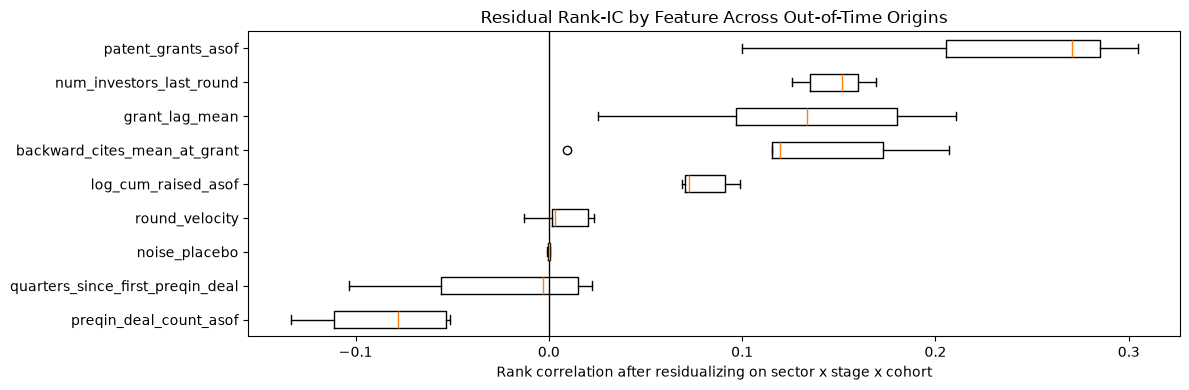

In [28]:
ic_rows = []
for window in windows:
    test = model_frame[model_frame["cohort_year"].between(window["test_start"], window["test_end"])].copy()
    for family, cols in FEATURE_FAMILIES.items():
        for col in cols:
            if col in test.columns:
                ic_rows.append({"origin": window["origin"], "family": family, "feature": col, "residual_rank_ic": residual_rank_ic(test, col)})

ic = pd.DataFrame(ic_rows)
ic.to_csv(OUTPUT_DIR / "residual_rank_ic_by_origin.csv", index=False)
display(ic.groupby(["family", "feature"], as_index=False)["residual_rank_ic"].agg(["mean", "std", "count"]).reset_index())

plot_data = ic.dropna(subset=["residual_rank_ic"]).copy()
if plot_data.empty:
    print("No non-null residual rank-IC values to plot. Check window support and feature variation.")
else:
    fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * plot_data["feature"].nunique())))
    ordered = plot_data.groupby("feature")["residual_rank_ic"].median().sort_values().index.tolist()
    box_values = [plot_data.loc[plot_data["feature"] == feature, "residual_rank_ic"].to_numpy() for feature in ordered]
    try:
        ax.boxplot(box_values, vert=False, tick_labels=ordered)
    except TypeError:
        ax.boxplot(box_values, vert=False, labels=ordered)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title("Residual Rank-IC by Feature Across Out-of-Time Origins")
    ax.set_xlabel("Rank correlation after residualizing on sector x stage x cohort")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "residual_rank_ic_feature_boxplot.png", dpi=160)
    plt.show()


## Model Harness: Placebo First, Then Real Families

Traditional classification metrics (`Accuracy`, `Precision`, `Recall`, `F1`) are reported as diagnostics only using a fixed 0.5 probability threshold. They are not used for feature-family promotion gates, which remain based on pooled out-of-time Precision@500 lift, bootstrap confidence intervals, sign consistency, and calibration.

## Metric Definitions

| Metric | Meaning | Direction | Used for promotion gate? |
|---|---|---:|---:|
| `Origins` | Number of mature out-of-time rolling test windows included in the summary. | Higher support is better | No |
| `Mean Window Precision@500` | In the model harness table, each mature out-of-time window is ranked separately, top 500 is scored separately, and the window precisions are averaged. | Higher is better | Diagnostic |
| `Pooled Precision@500` | In the promotion-gate table, all out-of-time predictions are pooled together, ranked once, and the single global top 500 is scored. | Higher is better | Yes |
| `Delta vs baseline` | Variant precision minus the same model's frozen baseline precision under the same table's precision definition. | Higher is better | Yes |
| `95% bootstrap CI` | Bootstrap confidence interval for `Delta vs baseline` in pooled out-of-time predictions. | CI should exclude zero on the positive side | Yes |
| `PR-AUC` | Area under the precision-recall curve across all thresholds. Useful under class imbalance. | Higher is better | Diagnostic |
| `Brier` | Mean squared error of predicted probabilities versus labels. Measures probability quality. | Lower is better | Calibration diagnostic |
| `Brier Delta` | Variant `Brier` minus baseline `Brier`. Negative means the variant improves Brier score. | Lower / negative is better | Yes, as calibration guardrail |
| `ECE` | Expected Calibration Error from probability bins. Measures calibration gap. | Lower is better | Calibration diagnostic |
| `ECE Delta` | Variant `ECE` minus baseline `ECE`. Negative means calibration improves. | Lower / negative is better | Yes, as calibration guardrail |
| `Accuracy (diagnostic)` | Fixed-threshold 0.5 classification accuracy. | Higher is better | No |
| `Precision (diagnostic)` | Fixed-threshold 0.5 positive predictive value. | Higher is better | No |
| `Recall (diagnostic)` | Fixed-threshold 0.5 true positive rate. | Higher is better | No |
| `F1 (diagnostic)` | Harmonic mean of fixed-threshold precision and recall. | Higher is better | No |

The promotion protocol intentionally does not use accuracy or F1. They are included only as a familiar diagnostic reference.

In [29]:
def evaluate_feature_set(feature_set_name: str, extra_numeric: list[str], model_name: str, estimator) -> tuple[pd.DataFrame, pd.DataFrame]:
    pred_frames = []
    metric_rows = []
    numeric_cols = BASELINE_NUMERIC + extra_numeric
    categorical_cols = BASELINE_CATEGORICAL
    for window in windows:
        test_start_date = pd.Timestamp(year=window["test_start"], month=1, day=1)
        train_full = model_frame[model_frame["label_cutoff"] < test_start_date].copy()
        test = model_frame[model_frame["cohort_year"].between(window["test_start"], window["test_end"])].copy()
        train_full, test = add_train_gap_z(train_full, test)
        train = cap_train_rows(train_full, model_name)
        print(f"{model_name} | {feature_set_name} | origin={window['origin']} | train={len(train):,}/{len(train_full):,} | test={len(test):,}")
        score = fit_predict(train, test, numeric_cols, categorical_cols, estimator)
        pred_label = (score >= 0.5).astype(int)
        pred = test[["observation_id", "company_uuid", "review_date", "y", "cohort_year"]].copy()
        pred["origin"] = window["origin"]
        pred["feature_set"] = feature_set_name
        pred["model"] = model_name
        pred["score"] = score
        pred["rank"] = pred["score"].rank(method="first", ascending=False)
        pred["in_top_500"] = pred["rank"] <= min(PRECISION_K, len(pred))
        pred_frames.append(pred)
        metric_rows.append({
            "origin": window["origin"],
            "feature_set": feature_set_name,
            "model": model_name,
            "rows": len(test),
            "events": int(test["y"].sum()),
            "precision_at_500": precision_at_k(test["y"], score),
            "pr_auc": float(average_precision_score(test["y"], score)) if test["y"].nunique() == 2 else np.nan,
            "roc_auc": safe_auc(test["y"], score),
            "brier": float(brier_score_loss(test["y"], score)),
            "ece": expected_calibration_error(test["y"], score),
            "accuracy_diagnostic": float(accuracy_score(test["y"], pred_label)),
            "precision_diagnostic": float(precision_score(test["y"], pred_label, zero_division=0)),
            "recall_diagnostic": float(recall_score(test["y"], pred_label, zero_division=0)),
            "f1_diagnostic": float(f1_score(test["y"], pred_label, zero_division=0)),
        })
    return pd.concat(pred_frames, ignore_index=True), pd.DataFrame(metric_rows)


all_predictions = []
all_metrics = []
specs = model_specs()

feature_sets = {"baseline": [], "baseline_plus_placebo_noise": FEATURE_FAMILIES["placebo_noise"]}
for family in [name for name in FEATURE_FAMILIES if name != "placebo_noise"]:
    feature_sets[f"baseline_plus_{family}"] = FEATURE_FAMILIES[family]
feature_sets["all_real_features"] = ALL_REAL_FEATURES

for model_name, estimator in specs.items():
    for feature_set_name, cols in feature_sets.items():
        preds, metrics = evaluate_feature_set(feature_set_name, cols, model_name, estimator)
        all_predictions.append(preds)
        all_metrics.append(metrics)

predictions = pd.concat(all_predictions, ignore_index=True)
metrics = pd.concat(all_metrics, ignore_index=True)
predictions.to_csv(OUTPUT_DIR / "rolling_window_predictions.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "rolling_window_metrics.csv", index=False)

def display_variant_label(feature_set_name: str) -> str:
    if feature_set_name == "baseline":
        return "baseline"
    if feature_set_name == "baseline_plus_placebo_noise":
        return "baseline + noise_placebo"
    if str(feature_set_name).startswith("baseline_plus_"):
        return "baseline + " + str(feature_set_name).replace("baseline_plus_", "")
    if feature_set_name == "all_real_features":
        return "baseline + all_real_features"
    return str(feature_set_name)


model_window_summary = metrics.groupby(["model", "feature_set"], as_index=False).agg(
    Origins=("origin", "nunique"),
    **{
        "Mean Window Precision@500": ("precision_at_500", "mean"),
        "PR-AUC": ("pr_auc", "mean"),
        "Brier": ("brier", "mean"),
        "ECE": ("ece", "mean"),
        "Accuracy (diagnostic)": ("accuracy_diagnostic", "mean"),
        "Precision (diagnostic)": ("precision_diagnostic", "mean"),
        "Recall (diagnostic)": ("recall_diagnostic", "mean"),
        "F1 (diagnostic)": ("f1_diagnostic", "mean"),
    },
)
model_window_summary = model_window_summary.rename(columns={"model": "Model", "feature_set": "Variant"})
model_window_summary["Variant"] = model_window_summary["Variant"].map(display_variant_label)
baseline_summary = model_window_summary[model_window_summary["Variant"].eq("baseline")][["Model", "Mean Window Precision@500", "Brier", "ECE"]].rename(columns={
    "Mean Window Precision@500": "baseline_precision_at_500",
    "Brier": "baseline_brier",
    "ECE": "baseline_ece",
})
model_window_summary = model_window_summary.merge(baseline_summary, on="Model", how="left")
model_window_summary["Delta vs baseline"] = model_window_summary["Mean Window Precision@500"] - model_window_summary["baseline_precision_at_500"]
model_window_summary["Brier Delta"] = model_window_summary["Brier"] - model_window_summary["baseline_brier"]
model_window_summary["ECE Delta"] = model_window_summary["ECE"] - model_window_summary["baseline_ece"]
model_window_summary = model_window_summary[["Model", "Variant", "Origins", "Mean Window Precision@500", "Delta vs baseline", "PR-AUC", "Brier", "Brier Delta", "ECE", "ECE Delta", "Accuracy (diagnostic)", "Precision (diagnostic)", "Recall (diagnostic)", "F1 (diagnostic)"]]
display(model_window_summary)


logistic_regression | baseline | origin=2013 | train=150,000/1,207,219 | test=394,316
logistic_regression | baseline | origin=2015 | train=150,000/1,483,939 | test=483,571
logistic_regression | baseline | origin=2017 | train=150,000/1,796,353 | test=584,031
logistic_regression | baseline | origin=2019 | train=150,000/2,157,590 | test=691,692
logistic_regression | baseline | origin=2021 | train=150,000/2,593,175 | test=384,318
logistic_regression | baseline_plus_placebo_noise | origin=2013 | train=150,000/1,207,219 | test=394,316
logistic_regression | baseline_plus_placebo_noise | origin=2015 | train=150,000/1,483,939 | test=483,571
logistic_regression | baseline_plus_placebo_noise | origin=2017 | train=150,000/1,796,353 | test=584,031
logistic_regression | baseline_plus_placebo_noise | origin=2019 | train=150,000/2,157,590 | test=691,692
logistic_regression | baseline_plus_placebo_noise | origin=2021 | train=150,000/2,593,175 | test=384,318
logistic_regression | baseline_plus_syndicate

d:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


svm_rbf | baseline | origin=2015 | train=8,000/1,483,939 | test=483,571


d:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


svm_rbf | baseline | origin=2017 | train=8,000/1,796,353 | test=584,031


...

d:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


svm_rbf | all_real_features | origin=2021 | train=8,000/2,593,175 | test=384,318


d:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


xgboost | baseline | origin=2013 | train=80,000/1,207,219 | test=394,316
xgboost | baseline | origin=2015 | train=80,000/1,483,939 | test=483,571
xgboost | baseline | origin=2017 | train=80,000/1,796,353 | test=584,031
xgboost | baseline | origin=2019 | train=80,000/2,157,590 | test=691,692
xgboost | baseline | origin=2021 | train=80,000/2,593,175 | test=384,318
xgboost | baseline_plus_placebo_noise | origin=2013 | train=80,000/1,207,219 | test=394,316
xgboost | baseline_plus_placebo_noise | origin=2015 | train=80,000/1,483,939 | test=483,571
xgboost | baseline_plus_placebo_noise | origin=2017 | train=80,000/1,796,353 | test=584,031
xgboost | baseline_plus_placebo_noise | origin=2019 | train=80,000/2,157,590 | test=691,692
xgboost | baseline_plus_placebo_noise | origin=2021 | train=80,000/2,593,175 | test=384,318
xgboost | baseline_plus_syndicate_investor_supported | origin=2013 | train=80,000/1,207,219 | test=394,316
xgboost | baseline_plus_syndicate_investor_supported | origin=2015 |

,Model,Variant,Origins,Mean Window Precision@500,Delta vs baseline,PR-AUC,Brier,Brier Delta,ECE,ECE Delta,Accuracy (diagnostic),Precision (diagnostic),Recall (diagnostic),F1 (diagnostic)
0,logistic_regression,baseline + all_real_features,5,0.3972,-0.0692,0.255005,0.237498,1.642357e-03,0.276403,4.853049e-03,0.651035,0.192212,0.237382,0.210818
1,logistic_regression,baseline,5,0.4664,0.0000,0.228644,0.235856,0.000000e+00,0.271550,0.000000e+00,0.648522,0.169029,0.181336,0.166396
2,logistic_regression,baseline + buyout_fundamentals,5,0.4664,0.0000,0.228644,0.235856,-2.909478e-12,0.271550,-1.422251e-12,0.648522,0.169029,0.181336,0.166396
3,logistic_regression,baseline + founder_funding_dynamics_supported,5,0.2396,-0.2268,0.239006,0.236243,3.869408e-04,0.272726,1.175286e-03,0.670950,0.182144,0.182597,0.177627
4,logistic_regression,baseline + patent_quality,5,0.3996,-0.0668,0.227639,0.235970,1.140395e-04,0.271610,5.969029e-05,0.646451,0.168673,0.184286,0.168285
5,logistic_regression,baseline + noise_placebo,5,0.4220,-0.0444,0.227382,0.235614,-2.416997e-04,0.270914,-6.360298e-04,0.661565,0.172001,0.175419,0.166981
6,logistic_regression,baseline + preqin_institutional_confirmation,5,0.6156,0.1492,0.251328,0.237067,1.210860e-03,0.275475,3.924796e-03,0.660912,0.193543,0.224553,0.206148
7,logistic_regression,baseline + syndicate_investor_supported,5,0.5324,0.0660,0.236039,0.235011,-8.448676e-04,0.271457,-9.337782e-05,0.668448,0.179680,0.179023,0.173627
8,svm_rbf,baseline + all_real_features,5,0.3172,-0.0548,0.212255,0.161529,-1.194918e-03,0.094182,3.579680e-03,0.804422,0.000000,0.000000,0.000000
9,svm_rbf,baseline,5,0.3720,0.0000,0.201473,0.162724,0.000000e+00,0.090602,0.000000e+00,0.804422,0.000000,0.000000,0.000000


### Label and Top-500 Diagnostics

Use this table to sanity-check unusually high top-500 precision. If the test-window label prevalence is already very high, or top-500 counts are nearly all positive for the baseline, the task is not discriminating enough. If only one feature family jumps to perfect top-500 precision, inspect that family for leakage.

In [30]:
label_window_diagnostics = predictions.groupby(["model", "feature_set", "origin"], as_index=False).agg(
    test_rows=("y", "size"),
    test_events=("y", "sum"),
    test_prevalence=("y", "mean"),
    top500_rows=("in_top_500", "sum"),
    top500_events=("y", lambda s: int(s[predictions.loc[s.index, "in_top_500"]].sum())),
)
label_window_diagnostics["top500_precision"] = label_window_diagnostics["top500_events"] / label_window_diagnostics["top500_rows"].replace(0, np.nan)
label_window_diagnostics["Variant"] = label_window_diagnostics["feature_set"].map(display_variant_label)
label_window_diagnostics = label_window_diagnostics.rename(columns={"model": "Model", "origin": "Origin"})[
    ["Model", "Variant", "Origin", "test_rows", "test_events", "test_prevalence", "top500_rows", "top500_events", "top500_precision"]
]
label_window_diagnostics.to_csv(OUTPUT_DIR / "label_top500_diagnostics.csv", index=False)
display(label_window_diagnostics.sort_values(["Model", "Variant", "Origin"]))


,Model,Variant,Origin,test_rows,test_events,test_prevalence,top500_rows,top500_events,top500_precision
5,logistic_regression,baseline,2013,394316,91229,0.231360,500,255,0.510
6,logistic_regression,baseline,2015,483571,102892,0.212775,500,266,0.532
7,logistic_regression,baseline,2017,584031,111807,0.191440,500,253,0.506
8,logistic_regression,baseline,2019,691692,118362,0.171120,500,201,0.402
9,logistic_regression,baseline,2021,384318,65793,0.171194,500,205,0.410
...,...,...,...,...,...,...,...,...,...
115,xgboost,baseline + syndicate_investor_supported,2013,394316,91229,0.231360,500,319,0.638
116,xgboost,baseline + syndicate_investor_supported,2015,483571,102892,0.212775,500,331,0.662
117,xgboost,baseline + syndicate_investor_supported,2017,584031,111807,0.191440,500,303,0.606
118,xgboost,baseline + syndicate_investor_supported,2019,691692,118362,0.171120,500,325,0.650


## Family Promotion Gates

A family passes only when it beats the frozen baseline on pooled Precision@500 with bootstrap CI excluding zero, has a consistent positive sign across origins, and does not damage calibration. The placebo is evaluated first; if it passes, the gate is invalid.

In [31]:
def format_pct(value: float) -> str:
    return "" if pd.isna(value) else f"{100 * value:.2f}%"


def format_signed_pct(value: float) -> str:
    return "" if pd.isna(value) else f"{100 * value:+.2f}%"


def format_signed_float(value: float) -> str:
    return "" if pd.isna(value) else f"{value:+.6f}"


def variant_label(feature_set_name: str) -> str:
    if feature_set_name == "baseline":
        return "baseline"
    if feature_set_name == "baseline_plus_placebo_noise":
        return "baseline + noise_placebo"
    if feature_set_name.startswith("baseline_plus_"):
        return "baseline + " + feature_set_name.replace("baseline_plus_", "")
    if feature_set_name == "all_real_features":
        return "baseline + all_real_features"
    return feature_set_name


promotion_rows = []
pooled_rows = []
for model_name in specs:
    base_preds = predictions[(predictions["model"] == model_name) & (predictions["feature_set"] == "baseline")].copy()
    base_metrics = metrics[(metrics["model"] == model_name) & (metrics["feature_set"] == "baseline")].copy()
    base_p500 = precision_at_k(base_preds["y"], base_preds["score"])
    pooled_rows.append({
        "Model": model_name,
        "Variant": "baseline",
        "Pooled Precision@500": base_p500,
        "Delta vs baseline": 0.0,
        "95% bootstrap CI": "--",
        "Brier Delta": 0.0,
        "ECE Delta": 0.0,
    })
    for feature_set_name in [name for name in feature_sets if name != "baseline"]:
        alt_preds = predictions[(predictions["model"] == model_name) & (predictions["feature_set"] == feature_set_name)].copy()
        alt_metrics = metrics[(metrics["model"] == model_name) & (metrics["feature_set"] == feature_set_name)].copy()
        delta, lo, hi = bootstrap_delta_ci(base_preds, alt_preds)
        alt_p500 = precision_at_k(alt_preds["y"], alt_preds["score"])
        merged_metrics = base_metrics[["origin", "precision_at_500", "brier", "ece"]].rename(columns={
            "precision_at_500": "p500_base", "brier": "brier_base", "ece": "ece_base"
        }).merge(alt_metrics[["origin", "precision_at_500", "brier", "ece"]].rename(columns={
            "precision_at_500": "p500_alt", "brier": "brier_alt", "ece": "ece_alt"
        }), on="origin")
        origin_deltas = merged_metrics["p500_alt"] - merged_metrics["p500_base"]
        consistent_sign = int((origin_deltas > 0).mean() >= MIN_POSITIVE_ORIGIN_SHARE)
        calibration_intact = int((merged_metrics["brier_alt"].mean() <= merged_metrics["brier_base"].mean() + 0.005) and (merged_metrics["ece_alt"].mean() <= merged_metrics["ece_base"].mean() + 0.01))
        ci_excludes_zero = int(lo > 0 or hi < 0)
        practical_lift_gate = int(delta >= MIN_PROMOTION_DELTA)
        ci_lower_gate = int(lo >= MIN_PROMOTION_CI_LOWER)
        passed = int(practical_lift_gate and ci_lower_gate and consistent_sign and calibration_intact)
        promotion_rows.append({
            "model": model_name,
            "feature_set": feature_set_name,
            "delta_precision_at_500": delta,
            "delta_ci_2p5": lo,
            "delta_ci_97p5": hi,
            "ci_excludes_zero": ci_excludes_zero,
            "practical_lift_gate": practical_lift_gate,
            "ci_lower_gate": ci_lower_gate,
            "positive_origin_share": float((origin_deltas > 0).mean()),
            "consistent_sign_gate": consistent_sign,
            "mean_brier_delta": float((merged_metrics["brier_alt"] - merged_metrics["brier_base"]).mean()),
            "mean_ece_delta": float((merged_metrics["ece_alt"] - merged_metrics["ece_base"]).mean()),
            "calibration_intact_gate": calibration_intact,
            "promotion_pass": passed,
        })
        pooled_rows.append({
            "Model": model_name,
            "Variant": variant_label(feature_set_name),
            "Pooled Precision@500": alt_p500,
            "Delta vs baseline": delta,
            "95% bootstrap CI": f"[{format_signed_pct(lo)}, {format_signed_pct(hi)}]",
            "Brier Delta": float((merged_metrics["brier_alt"] - merged_metrics["brier_base"]).mean()),
            "ECE Delta": float((merged_metrics["ece_alt"] - merged_metrics["ece_base"]).mean()),
        })

promotion = pd.DataFrame(promotion_rows)
pooled_oot_results = pd.DataFrame(pooled_rows)
pooled_oot_results_display = pooled_oot_results.copy()
pooled_oot_results_display["Pooled Precision@500"] = pooled_oot_results_display["Pooled Precision@500"].map(format_pct)
pooled_oot_results_display["Delta vs baseline"] = pooled_oot_results_display["Delta vs baseline"].map(format_signed_pct)
pooled_oot_results_display["Brier Delta"] = pooled_oot_results_display["Brier Delta"].map(format_signed_float)
pooled_oot_results_display["ECE Delta"] = pooled_oot_results_display["ECE Delta"].map(format_signed_float)
placebo_passes = promotion[promotion["feature_set"].eq("baseline_plus_placebo_noise") & promotion["promotion_pass"].eq(1)]
promotion["promotion_gate_valid"] = int(placebo_passes.empty)
promotion.to_csv(OUTPUT_DIR / "family_promotion_gates.csv", index=False)
pooled_oot_results.to_csv(OUTPUT_DIR / "pooled_out_of_time_results.csv", index=False)
display(pooled_oot_results_display.sort_values(["Model", "Variant"]))
display(promotion.sort_values(["model", "feature_set"]))
if not placebo_passes.empty:
    print("WARNING: noise placebo still passed promotion gate. Treat all promotion results as invalid until thresholds or label design are revised.")
    display(placebo_passes)
    if PLACEBO_PASS_IS_FATAL:
        raise RuntimeError("Noise placebo passed a promotion gate. Thresholds are wrong; do not trust real-family promotion results.")
else:
    print("Noise placebo did not pass promotion gates. Proceed to inspect real feature families.")


,Model,Variant,Pooled Precision@500,Delta vs baseline,95% bootstrap CI,Brier Delta,ECE Delta
0,logistic_regression,baseline,50.80%,+0.00%,--,+0.000000,+0.000000
7,logistic_regression,baseline + all_real_features,12.20%,-38.60%,"[-44.60%, -33.20%]",+0.001642,+0.004853
6,logistic_regression,baseline + buyout_fundamentals,50.80%,+0.00%,"[+0.00%, +0.00%]",-0.000000,-0.000000
3,logistic_regression,baseline + founder_funding_dynamics_supported,11.60%,-39.20%,"[-45.40%, -33.80%]",+0.000387,+0.001175
1,logistic_regression,baseline + noise_placebo,35.40%,-15.40%,"[-20.40%, -11.00%]",-0.000242,-0.000636
4,logistic_regression,baseline + patent_quality,49.80%,-1.00%,"[-2.30%, +0.20%]",+0.000114,+0.000060
5,logistic_regression,baseline + preqin_institutional_confirmation,61.60%,+10.80%,"[+4.49%, +16.70%]",+0.001211,+0.003925
2,logistic_regression,baseline + syndicate_investor_supported,54.20%,+3.40%,"[-2.00%, +11.00%]",-0.000845,-0.000093
8,svm_rbf,baseline,41.60%,+0.00%,--,+0.000000,+0.000000
15,svm_rbf,baseline + all_real_features,31.00%,-10.60%,"[-19.91%, -8.40%]",-0.001195,+0.003580


,model,feature_set,delta_precision_at_500,delta_ci_2p5,delta_ci_97p5,ci_excludes_zero,practical_lift_gate,ci_lower_gate,positive_origin_share,consistent_sign_gate,mean_brier_delta,mean_ece_delta,calibration_intact_gate,promotion_pass,promotion_gate_valid
6,logistic_regression,all_real_features,-0.386,-0.44600,-0.33200,1,0,0,0.6,0,1.642357e-03,4.853049e-03,1,0,1
5,logistic_regression,baseline_plus_buyout_fundamentals,0.000,0.00000,0.00000,0,0,0,0.0,0,-2.909495e-12,-1.422246e-12,1,0,1
2,logistic_regression,baseline_plus_founder_funding_dynamics_supported,-0.392,-0.45400,-0.33800,1,0,0,0.0,0,3.869408e-04,1.175286e-03,1,0,1
3,logistic_regression,baseline_plus_patent_quality,-0.010,-0.02305,0.00200,0,0,0,0.0,0,1.140395e-04,5.969029e-05,1,0,1
0,logistic_regression,baseline_plus_placebo_noise,-0.154,-0.20400,-0.11000,1,0,0,0.4,0,-2.416997e-04,-6.360298e-04,1,0,1
4,logistic_regression,baseline_plus_preqin_institutional_confirmation,0.108,0.04495,0.16705,1,1,1,1.0,1,1.210860e-03,3.924796e-03,1,1,1
1,logistic_regression,baseline_plus_syndicate_investor_supported,0.034,-0.02000,0.11000,0,1,0,1.0,1,-8.448676e-04,-9.337782e-05,1,0,1
13,svm_rbf,all_real_features,-0.106,-0.19905,-0.08400,1,0,0,0.4,0,-1.194918e-03,3.579680e-03,1,0,1
12,svm_rbf,baseline_plus_buyout_fundamentals,0.058,-0.02200,0.02000,0,1,0,0.2,0,9.180270e-06,8.676108e-05,1,0,1
9,svm_rbf,baseline_plus_founder_funding_dynamics_supported,0.152,0.06800,0.18905,1,1,1,0.6,0,-9.079658e-04,-3.312311e-03,1,0,1


Noise placebo did not pass promotion gates. Proceed to inspect real feature families.


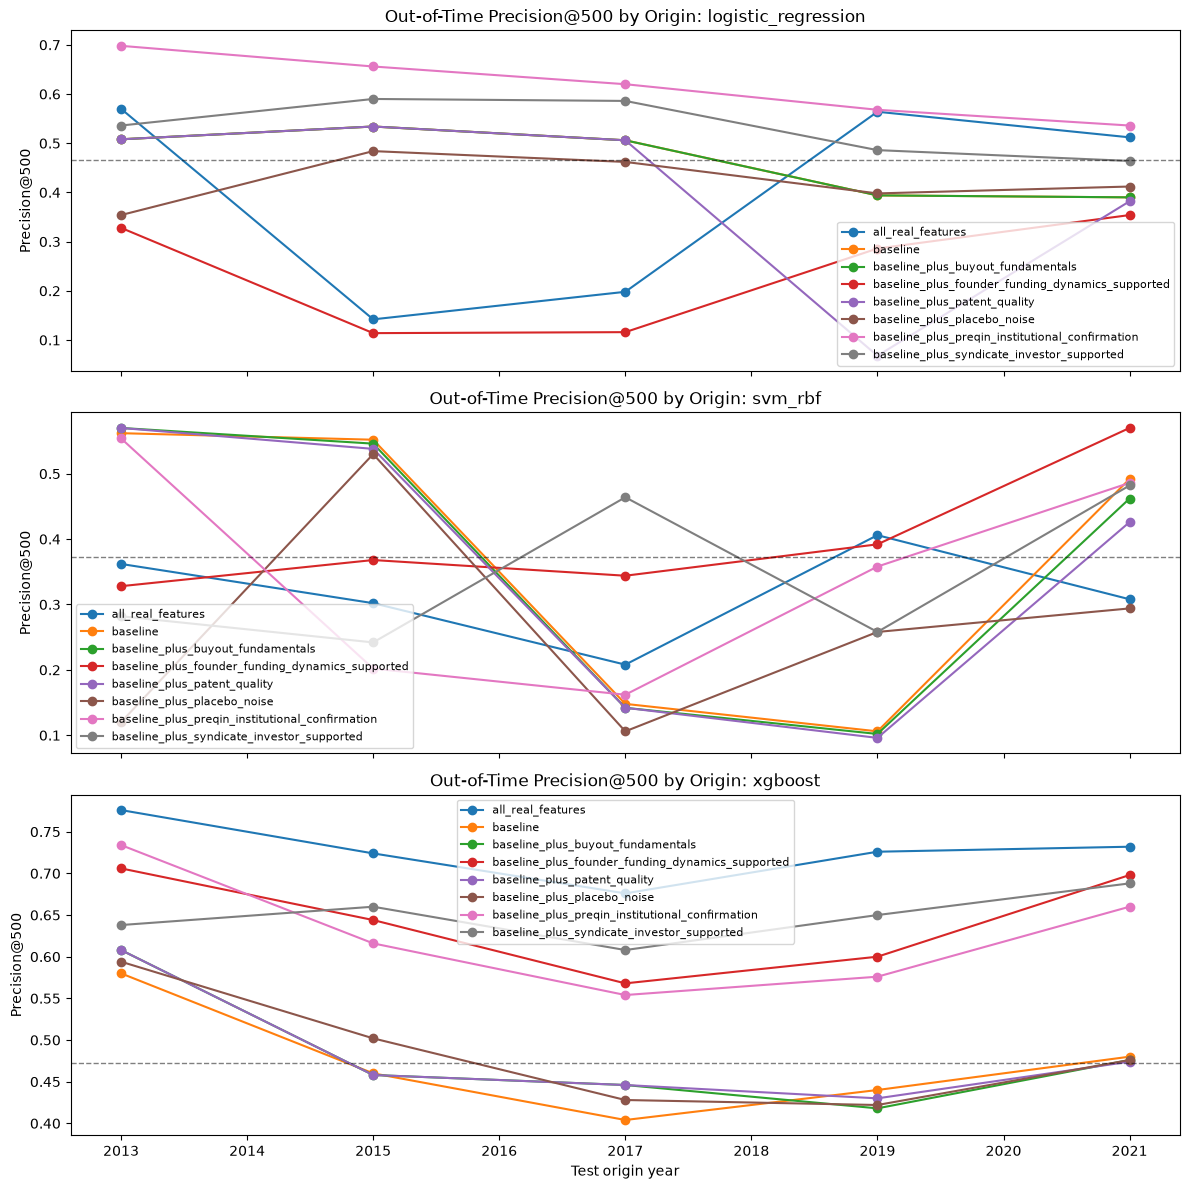

Artifacts written to: d:\Columbia\SummerProject\L3_9_2_VC_and_PE_Exit_Prediction_distribution\outputs\live_root_harness


In [32]:
fig, axes = plt.subplots(len(specs), 1, figsize=(12, 4 * len(specs)), sharex=True)
if len(specs) == 1:
    axes = [axes]
for ax, model_name in zip(axes, specs.keys()):
    subset = metrics[metrics["model"] == model_name]
    for feature_set_name, group in subset.groupby("feature_set"):
        ax.plot(group["origin"], group["precision_at_500"], marker="o", label=feature_set_name)
    ax.set_title(f"Out-of-Time Precision@500 by Origin: {model_name}")
    ax.set_ylabel("Precision@500")
    ax.axhline(subset[subset["feature_set"] == "baseline"]["precision_at_500"].mean(), color="black", linewidth=1, linestyle="--", alpha=0.5)
    ax.legend(loc="best", fontsize=8)
axes[-1].set_xlabel("Test origin year")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "oot_precision_at_500_by_origin.png", dpi=160)
plt.show()

print(f"Artifacts written to: {OUTPUT_DIR}")
